# Análise Exploratória e Modelagem Preditiva do Consumo de Combustível utilizando o Dataset mtcars

## Objetivo

Este projeto realiza uma investigação exploratória do clássico dataset **mtcars**, buscando compreender quais características influenciam o consumo de combustível (mpg) dos veículos.

Durante a análise serão utilizados:

- Estatística descritiva
- Correlação
- Visualizações
- Regressão Linear

Ao final serão discutidos os principais resultados obtidos.

In [606]:
# ============================================================
# Importação das bibliotecas
# ============================================================
# Nesta etapa são importadas todas as bibliotecas necessárias
# para realizar a análise exploratória, a modelagem estatística
# e a construção dos modelos de Machine Learning.
# ============================================================

# Manipulação e organização dos dados
import pandas as pd
import numpy as np

# Criação de gráficos e visualizações
import matplotlib.pyplot as plt
import seaborn as sns

# Bibliotecas para testes estatísticos e regressão linear
import scipy.stats as stats
import statsmodels.api as sma
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Métricas utilizadas para avaliar os modelos desenvolvidos
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Modelo de Regressão Linear
from sklearn.linear_model import LinearRegression

# Ferramentas para dividir os dados em treino e teste e
# validar o desempenho do modelo utilizando validação cruzada.
from sklearn.model_selection import train_test_split

In [607]:
# ============================================================
# Configuração do ambiente de visualização
# ============================================================
# Antes de iniciar a análise, definimos um estilo padrão para
# todos os gráficos. Isso garante uma aparência mais limpa e
# facilita a comparação entre as diferentes visualizações que
# serão geradas ao longo do notebook.

sns.set_theme(style="whitegrid")

# Também definimos um tamanho padrão para as figuras,
# evitando repetir essa configuração em cada gráfico.
plt.rcParams["figure.figsize"] = (10, 6)

In [608]:
# ============================================================
# Carregamento do conjunto de dados
# ============================================================
# Nesta etapa, o dataset MTCars é carregado para um DataFrame
# do Pandas, estrutura que permite manipular e analisar os
# dados de forma eficiente.

mtcars = pd.read_csv("./mt_cars.csv")

# Como primeira verificação, exibimos a quantidade de linhas
# (observações) e colunas (variáveis) presentes no conjunto
# de dados. Essa conferência ajuda a garantir que o arquivo
# foi carregado corretamente antes de iniciar a análise.

print(f'Linhas: {mtcars.shape[0]}')
print(f'Colunas: {mtcars.shape[1]}')

Linhas: 32
Colunas: 12


## Sobre o dataset

O **mtcars** é um dos conjuntos de dados mais conhecidos da linguagem **R** e é amplamente utilizado para fins educacionais e estudos de Estatística, Ciência de Dados e Machine Learning.

O conjunto contém informações de **32 automóveis** comercializados na década de 1970, reunindo características mecânicas e de desempenho dos veículos. Neste projeto, o objetivo é investigar como essas características influenciam o consumo de combustível.

### Variável alvo

- **mpg:** Milhas percorridas por galão de combustível (*Miles Per Gallon*).

### Principais variáveis explicativas

- **cyl:** Número de cilindros do motor.
- **disp:** Cilindrada do motor.
- **hp:** Potência do motor (*Horsepower*).
- **drat:** Relação do eixo traseiro.
- **wt:** Peso do veículo.
- **qsec:** Tempo necessário para percorrer 1/4 de milha.
- **vs:** Tipo do motor (0 = V, 1 = em linha).
- **am:** Tipo de transmissão (0 = automática, 1 = manual).
- **gear:** Número de marchas da transmissão.
- **carb:** Número de carburadores.

In [609]:
# ============================================================
# Primeiras observações do conjunto de dados
# ============================================================
# Exibimos as primeiras linhas do DataFrame para conhecer sua
# estrutura, verificar o formato das colunas e confirmar que
# os dados foram carregados corretamente.

mtcars.head()

,Unnamed: 0,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [610]:
# ============================================================
# Informações gerais do dataset
# ============================================================
# O método info() fornece uma visão geral do conjunto de dados,
# incluindo:
#
# • quantidade de registros;
# • nomes das colunas;
# • tipos de dados;
# • quantidade de valores não nulos.
#
# Essas informações são importantes para identificar possíveis
# inconsistências antes de iniciar a análise.

mtcars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  32 non-null     object 
 1   mpg         32 non-null     float64
 2   cyl         32 non-null     int64  
 3   disp        32 non-null     float64
 4   hp          32 non-null     int64  
 5   drat        32 non-null     float64
 6   wt          32 non-null     float64
 7   qsec        32 non-null     float64
 8   vs          32 non-null     int64  
 9   am          32 non-null     int64  
 10  gear        32 non-null     int64  
 11  carb        32 non-null     int64  
dtypes: float64(5), int64(6), object(1)
memory usage: 3.1+ KB


In [611]:
# ============================================================
# Remoção de colunas não utilizadas
# ============================================================
# A coluna "Unnamed: 0" contém apenas o nome dos veículos.
# Como ela não representa uma característica numérica capaz de
# explicar o consumo de combustível, sua remoção evita que ela
# interfira nas análises estatísticas e nos modelos de Machine
# Learning.

mtcars = mtcars.drop(['Unnamed: 0'], axis=1)

## Análise Exploratória dos Dados (EDA)

In [612]:
# ============================================================
# Estatísticas descritivas
# ============================================================
# Nesta etapa analisamos um resumo estatístico das variáveis
# numéricas do conjunto de dados.
#
# Entre as informações apresentadas estão:
#
# • quantidade de observações;
# • média;
# • desvio padrão;
# • valores mínimo e máximo;
# • quartis (25%, 50% e 75%).
#
# Essas estatísticas ajudam a compreender a distribuição dos
# dados e servem como base para identificar possíveis
# discrepâncias ou padrões antes da modelagem.

mtcars.describe().T

,count,mean,std,min,25%,50%,75%,max
mpg,32.0,20.090625,6.026948,10.400,15.42500,19.200,22.80,33.900
cyl,32.0,6.187500,1.785922,4.000,4.00000,6.000,8.00,8.000
disp,32.0,230.721875,123.938694,71.100,120.82500,196.300,326.00,472.000
hp,32.0,146.687500,68.562868,52.000,96.50000,123.000,180.00,335.000
drat,32.0,3.596563,0.534679,2.760,3.08000,3.695,3.92,4.930
wt,32.0,3.217250,0.978457,1.513,2.58125,3.325,3.61,5.424
qsec,32.0,17.848750,1.786943,14.500,16.89250,17.710,18.90,22.900
vs,32.0,0.437500,0.504016,0.000,0.00000,0.000,1.00,1.000
am,32.0,0.406250,0.498991,0.000,0.00000,0.000,1.00,1.000
gear,32.0,3.687500,0.737804,3.000,3.00000,4.000,4.00,5.000


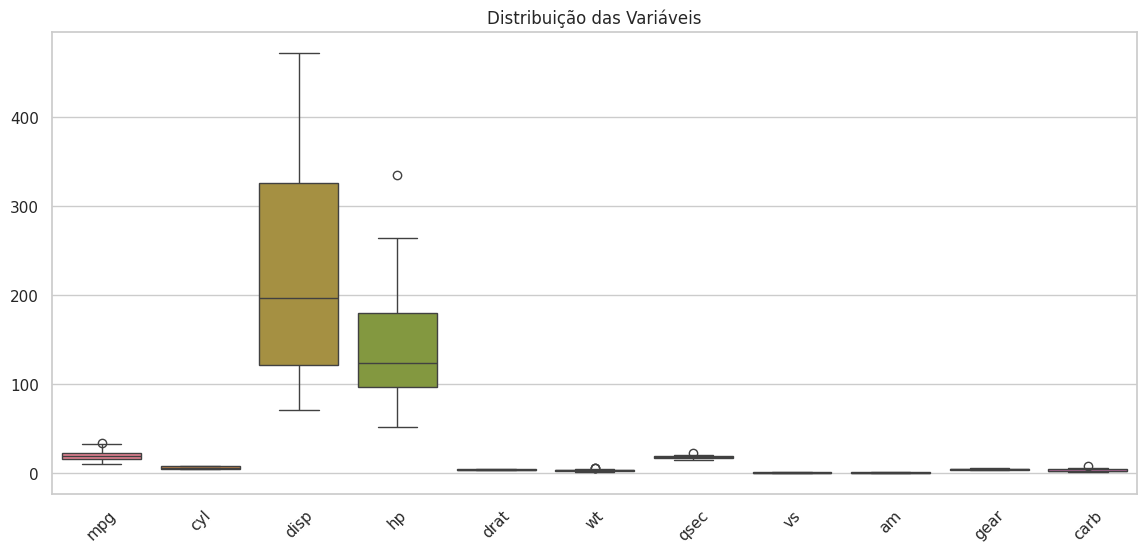

In [613]:
# ============================================================
# Análise de Outliers com Boxplot
# ============================================================
# O boxplot permite visualizar a distribuição de cada variável
# numérica do conjunto de dados em um único gráfico.
#
# Além da mediana e da dispersão dos valores, ele facilita a
# identificação de possíveis outliers (valores muito distantes
# do comportamento da maioria das observações).
#
# Nesta etapa, o objetivo é verificar se existem variáveis que
# apresentam valores extremos capazes de influenciar as análises
# estatísticas ou o desempenho dos modelos de Machine Learning.

plt.figure(figsize=(14,6))

sns.boxplot(data=mtcars)

# Rotaciona os nomes das variáveis para facilitar a leitura.
plt.xticks(rotation=45)

plt.title("Distribuição das Variáveis")

plt.show()

### Interpretação

O boxplot mostra que algumas variáveis apresentam observações mais distantes da distribuição principal, como **hp**, **wt**, **qsec**, **mpg** e **carb**.

Esses pontos são classificados como potenciais outliers pelo critério do boxplot (1,5 × IQR). Entretanto, isso **não significa necessariamente que sejam erros**. No contexto do dataset **mtcars**, eles podem representar veículos com características mecânicas incomuns, mas reais.

Por esse motivo, nesta investigação os valores serão mantidos, sendo apenas identificados e analisados ao longo do estudo.

In [614]:
# ============================================================
# Identificação de outliers utilizando o método IQR
# ============================================================
# Além da inspeção visual realizada com o boxplot, utilizamos
# o método do Intervalo Interquartil (IQR) para identificar,
# de forma objetiva, possíveis valores extremos.
#
# Um valor é considerado um potencial outlier quando está:
#
# • abaixo de Q1 - 1,5 × IQR
# • acima de Q3 + 1,5 × IQR
#
# onde:
# Q1 = primeiro quartil (25%)
# Q3 = terceiro quartil (75%)
# IQR = intervalo interquartil (Q3 - Q1)

Q1 = mtcars.quantile(0.25)

Q3 = mtcars.quantile(0.75)

IQR = Q3 - Q1

outliers_iqr = (
    (mtcars < (Q1 - 1.5 * IQR)) |
    (mtcars > (Q3 + 1.5 * IQR))
)

# Contabiliza a quantidade de outliers encontrados em cada variável.
outliers_iqr.sum()

,0
mpg,1
cyl,0
disp,0
hp,1
drat,0
wt,3
qsec,1
vs,0
am,0
gear,0


### Interpretação

A análise pelo método IQR identificou potenciais outliers nas variáveis **mpg**, **hp**, **wt**, **qsec** e **carb**.

Esses valores representam observações que estão afastadas da maior parte dos dados. No entanto, como o conjunto **mtcars** possui apenas 32 veículos e esses registros correspondem a automóveis reais, eles **não serão removidos** nesta investigação.

A decisão de manter esses valores preserva as características originais do dataset e evita a perda de informações potencialmente relevantes para a análise e para os modelos de Machine Learning.

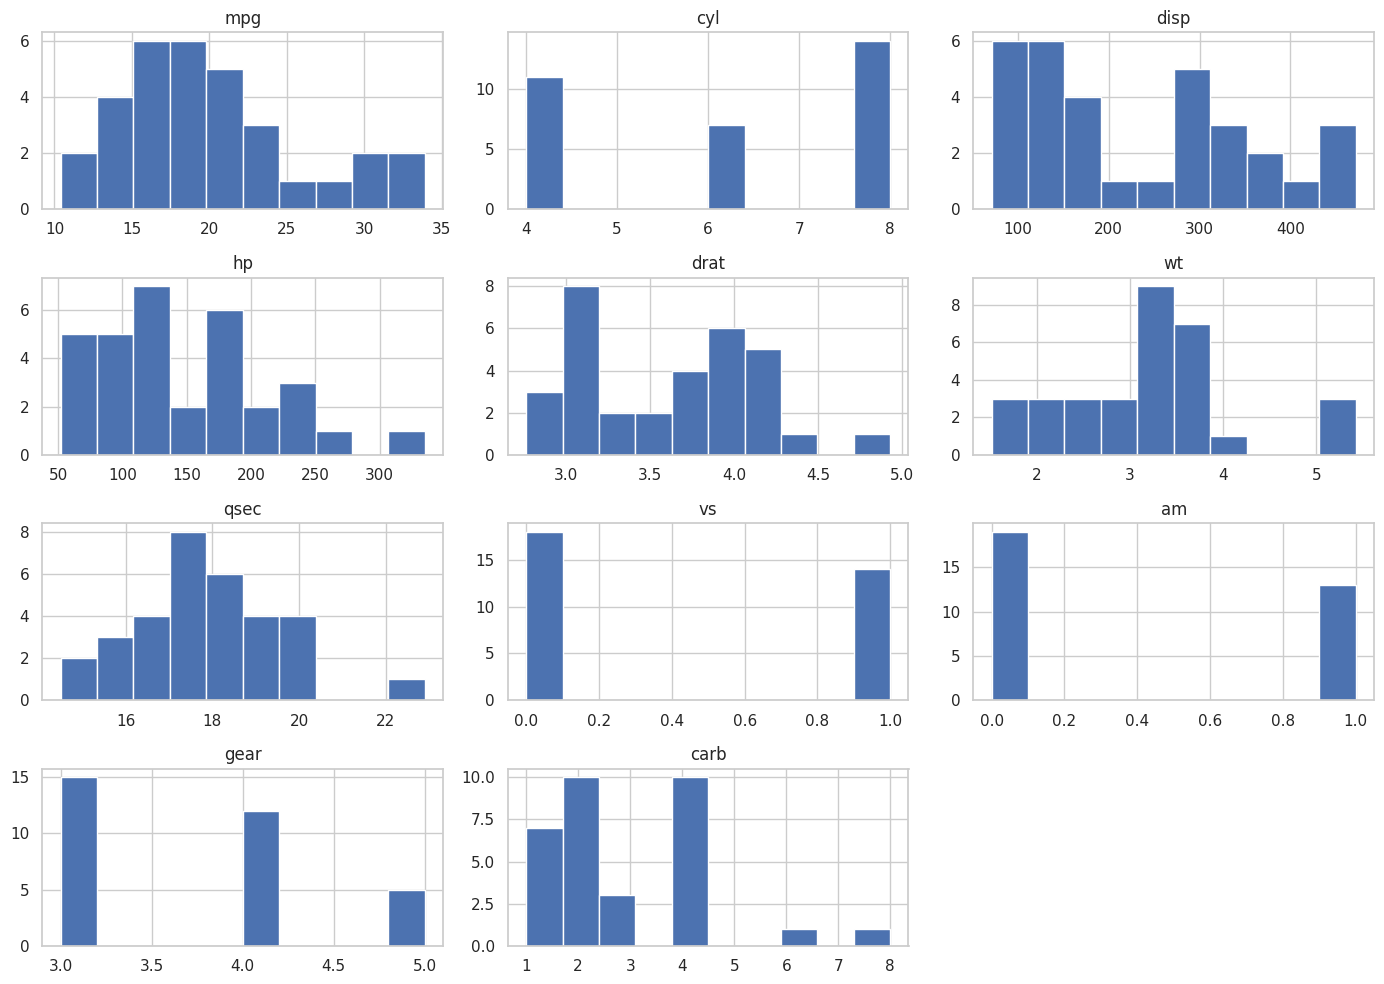

In [615]:
# ============================================================
# Distribuição das variáveis
# ============================================================
# Os histogramas permitem analisar como os valores de cada
# variável estão distribuídos ao longo do conjunto de dados.
#
# Essa visualização ajuda a identificar características como:
#
# • concentração dos valores;
# • assimetria da distribuição;
# • possíveis múltiplos grupos (multimodalidade);
# • presença de valores extremos.
#
# Essas informações são importantes para compreender o
# comportamento dos dados antes da construção dos modelos.

mtcars.hist(figsize=(14,10))

# Ajusta automaticamente o espaçamento entre os gráficos,
# evitando sobreposição de títulos e eixos.
plt.tight_layout()

### Interpretação

A análise dos histogramas mostra que as variáveis apresentam comportamentos bastante distintos.

- **mpg**, **drat**, **wt** e **qsec** possuem distribuições relativamente contínuas, embora algumas apresentem leve assimetria.
- **disp** e **hp** apresentam maior dispersão, indicando veículos com características mecânicas bastante diferentes entre si.
- As variáveis **cyl**, **gear** e **carb** assumem apenas alguns valores discretos, pois representam categorias numéricas.
- As variáveis **vs** e **am** são binárias, indicando dois grupos distintos de veículos.

Essas diferenças são esperadas e refletem a natureza de cada característica presente no conjunto de dados.

In [616]:
# ============================================================
# Verificação de valores ausentes
# ============================================================
# Antes de iniciar a modelagem, é importante verificar se o
# conjunto de dados possui valores ausentes (NaN).
#
# Dados incompletos podem comprometer análises estatísticas e
# afetar o desempenho dos algoritmos de Machine Learning.
#
# O método isnull().sum() contabiliza a quantidade de valores
# ausentes existente em cada variável do dataset.

mtcars.isnull().sum()

,0
mpg,0
cyl,0
disp,0
hp,0
drat,0
wt,0
qsec,0
vs,0
am,0
gear,0


### Interpretação

A verificação mostra que **nenhuma das variáveis possui valores ausentes**.

Isso significa que o conjunto de dados está completo e não será necessário aplicar técnicas de tratamento, como remoção de registros ou imputação de valores.

Essa característica simplifica as etapas seguintes da análise e permite utilizar todas as observações disponíveis na construção dos modelos.

## Correlação entre as variáveis

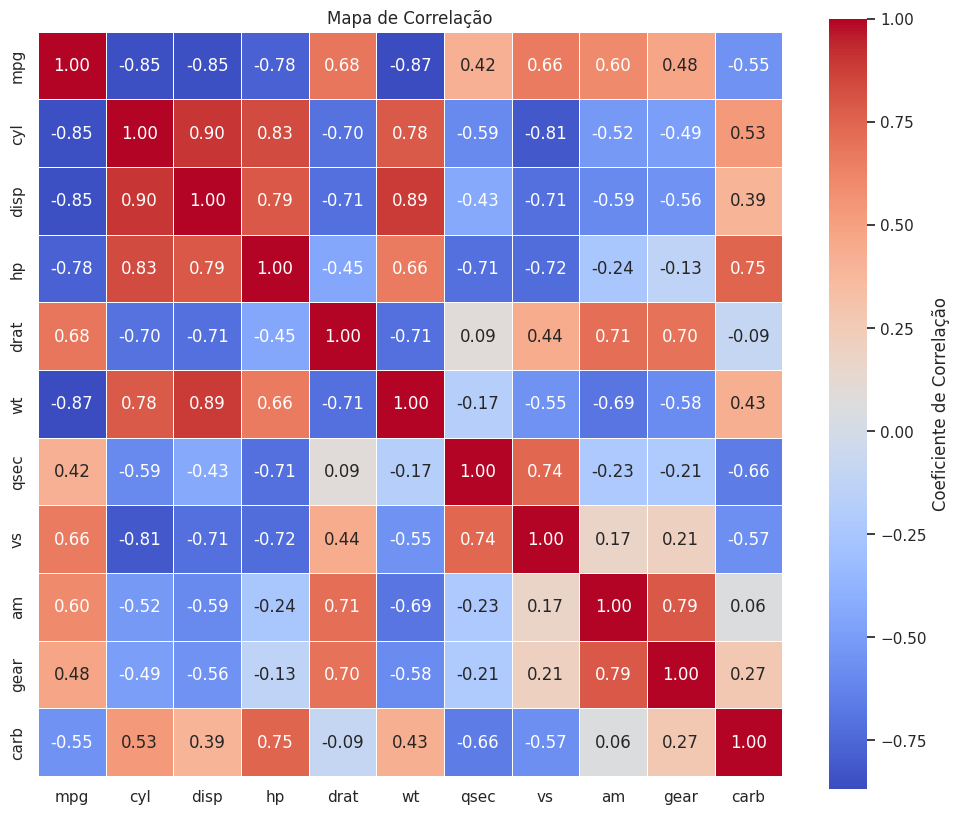

In [617]:
# ============================================================
# Matriz de Correlação
# ============================================================
# A correlação mede a intensidade e a direção da relação linear
# entre duas variáveis numéricas.
#
# O coeficiente de correlação de Pearson varia entre -1 e 1:
#
# • +1  → correlação positiva perfeita;
# • -1  → correlação negativa perfeita;
# •  0  → ausência de relação linear.
#
# O objetivo desta análise é identificar quais variáveis
# apresentam maior relação com o consumo de combustível (mpg)
# e verificar possíveis correlações elevadas entre as variáveis
# explicativas, situação conhecida como multicolinearidade.

corr = mtcars.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Coeficiente de Correlação"}
)

plt.title("Mapa de Correlação")

plt.show()

### Interpretação

O mapa de correlação permite identificar padrões importantes entre as variáveis do conjunto de dados.

Observando a variável alvo (**mpg**), nota-se que:

- **wt (-0,87)** apresenta a maior correlação negativa, indicando que veículos mais pesados tendem a consumir mais combustível.
- **disp (-0,85)** e **cyl (-0,85)** também possuem forte correlação negativa com o consumo.
- **hp (-0,78)** sugere que veículos mais potentes tendem a apresentar menor eficiência energética.
- **drat (0,68)**, **vs (0,66)** e **am (0,60)** possuem correlação positiva moderada com o consumo, indicando que essas características estão associadas a veículos mais econômicos.

Também é possível observar fortes correlações entre algumas variáveis explicativas, como:

- **cyl × disp (0,90)**
- **disp × wt (0,89)**
- **cyl × hp (0,83)**
- **am × gear (0,79)**

Essas relações sugerem a presença de **multicolinearidade**, situação em que variáveis independentes fornecem informações semelhantes. Esse comportamento será investigado posteriormente por meio do cálculo do **Variance Inflation Factor (VIF)**.

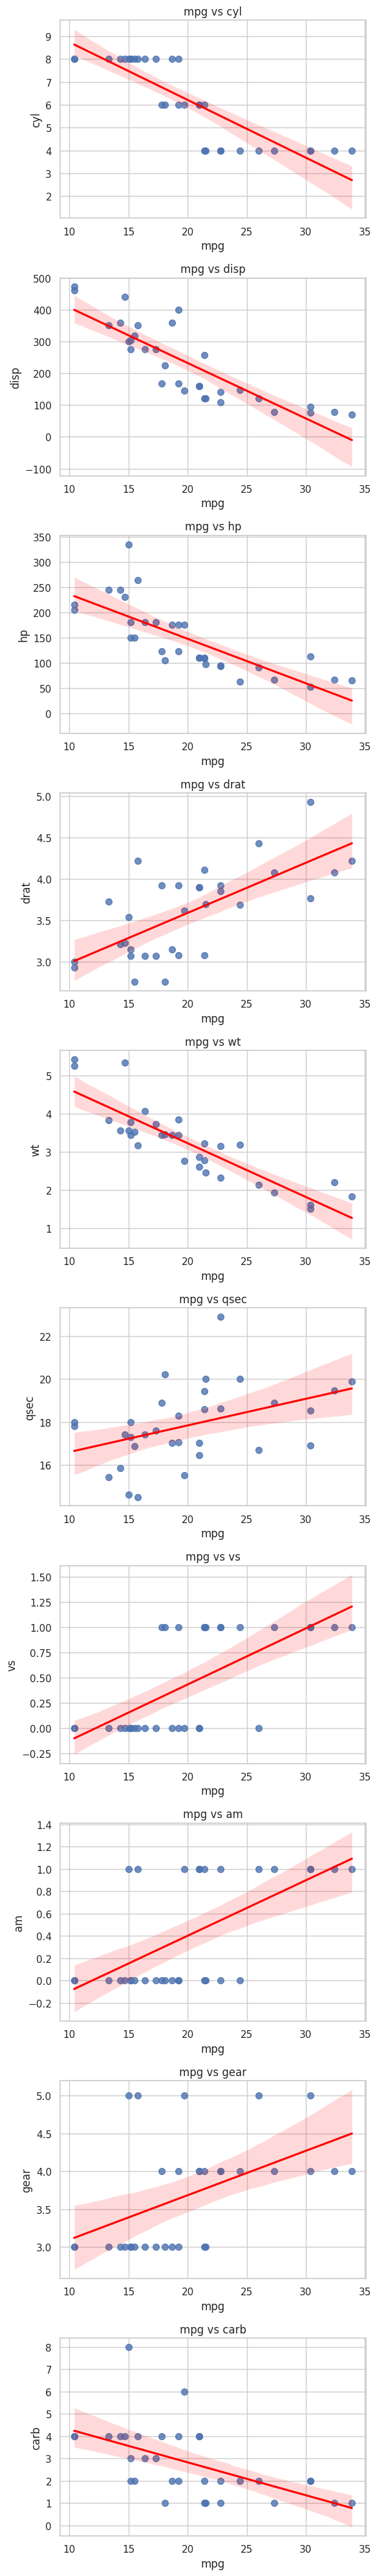

In [618]:
# ============================================================
# Gráficos de dispersão (Scatterplots)
# ============================================================
# Nesta etapa investigamos visualmente a relação entre a
# variável alvo (mpg) e cada uma das demais variáveis do
# conjunto de dados.
#
# Os gráficos de dispersão permitem observar:
#
# • tendências positivas ou negativas;
# • força da relação entre as variáveis;
# • possíveis agrupamentos;
# • valores atípicos (outliers);
# • indícios de relações não lineares.
#
# Essa análise complementa a matriz de correlação, permitindo
# interpretar visualmente os padrões existentes nos dados.

column_pairs = [
    ('mpg', 'cyl'),
    ('mpg', 'disp'),
    ('mpg', 'hp'),
    ('mpg', 'drat'),
    ('mpg', 'wt'),
    ('mpg', 'qsec'),
    ('mpg', 'vs'),
    ('mpg', 'am'),
    ('mpg', 'gear'),
    ('mpg', 'carb')
]

nplots = len(column_pairs)

fig, axes = plt.subplots(
    nrows=nplots,
    figsize=(6, 4 * nplots)
)

for i, (x_col, y_col) in enumerate(column_pairs):

    sns.regplot(
        x=x_col,
        y=y_col,
        data=mtcars,
        scatter_kws={"s":50},
        line_kws={"color":"red"},
        ax=axes[i]
    )

    axes[i].set_title(f'{x_col} vs {y_col}')

plt.tight_layout()

plt.show()

### Interpretação

Os gráficos de dispersão confirmam os padrões observados anteriormente na matriz de correlação.

As relações mais evidentes são:

- **wt × mpg:** forte tendência negativa, indicando que veículos mais pesados tendem a apresentar menor eficiência de combustível.
- **disp × mpg:** veículos com maior cilindrada geralmente apresentam menor consumo por galão.
- **hp × mpg:** observa-se uma relação negativa entre potência e eficiência energética.

Já as variáveis **drat** e **qsec** apresentam uma tendência positiva moderada, sugerindo que veículos com maior relação do eixo traseiro ou maior tempo para percorrer 1/4 de milha tendem a apresentar maior consumo por galão.

As variáveis **vs**, **am**, **gear** e **cyl** apresentam agrupamentos bem definidos, pois representam características discretas dos veículos, e não medidas contínuas.

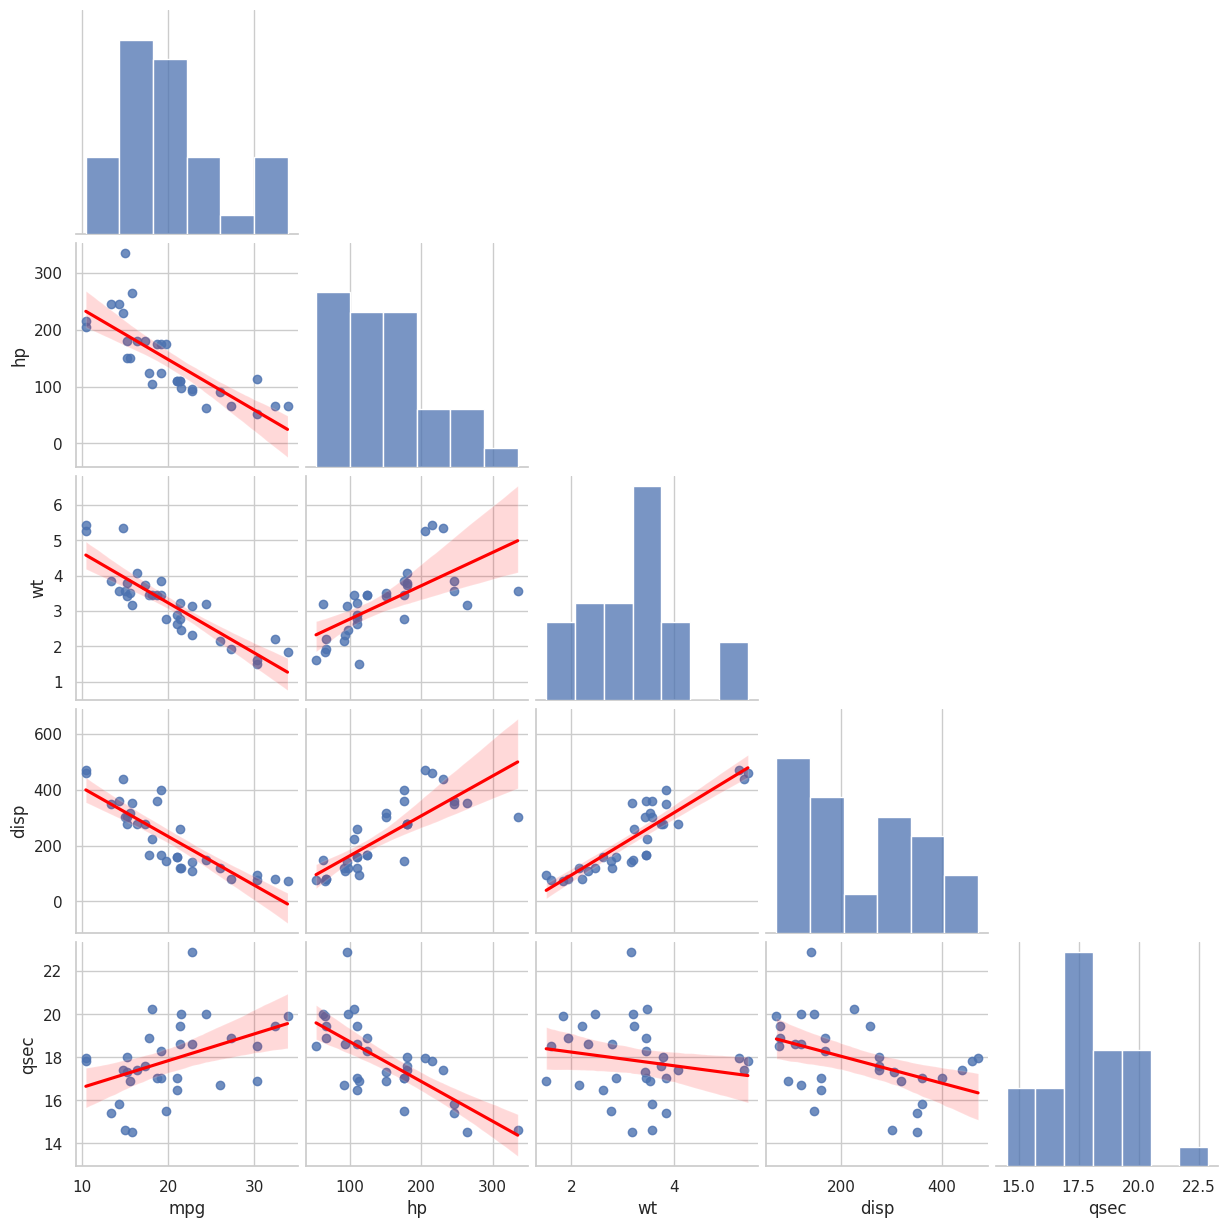

In [619]:
# ============================================================
# PairPlot - Relações entre as principais variáveis
# ============================================================
# O PairPlot reúne, em uma única visualização, histogramas e
# gráficos de dispersão para todas as combinações entre as
# principais variáveis numéricas do dataset.
#
# Essa ferramenta permite identificar:
#
# • distribuição individual das variáveis;
# • relações lineares entre pares de variáveis;
# • agrupamentos naturais;
# • possíveis outliers;
# • padrões que podem influenciar a construção dos modelos.
#
# Como o objetivo desta investigação é explicar o consumo de
# combustível (mpg), foram selecionadas apenas as variáveis
# numéricas mais relevantes para essa análise.

sns.pairplot(
    mtcars[['mpg', 'hp', 'wt', 'disp', 'qsec']],
    kind='reg',
    plot_kws={'line_kws': {'color': 'red'}},
    corner=True
)

plt.show()

### Interpretação

O PairPlot confirma diversas relações observadas anteriormente na matriz de correlação e nos gráficos de dispersão.

Os principais padrões encontrados foram:

- **mpg × wt:** apresenta a relação negativa mais evidente do conjunto de dados. À medida que o peso do veículo aumenta, observa-se uma redução consistente no consumo em milhas por galão.
- **mpg × hp:** veículos mais potentes tendem a apresentar menor eficiência de combustível.
- **mpg × disp:** automóveis com maior cilindrada geralmente apresentam menor consumo por galão.
- **wt × disp:** observa-se uma forte relação positiva, indicando que veículos mais pesados costumam possuir motores de maior cilindrada.
- **hp × disp:** motores maiores tendem a produzir maior potência.

Além disso, os histogramas presentes na diagonal mostram que algumas variáveis apresentam distribuições assimétricas, característica comum em conjuntos de dados reais.

De forma geral, o PairPlot reforça que **peso (wt)**, **cilindrada (disp)** e **potência (hp)** são as variáveis que apresentam maior associação com o consumo de combustível, justificando sua importância nas etapas de modelagem estatística.

In [620]:
# ============================================================
# Variance Inflation Factor (VIF)
# ============================================================
# Após analisar a matriz de correlação, calculamos o VIF
# (Variance Inflation Factor), uma métrica utilizada para
# identificar a presença de multicolinearidade entre as
# variáveis independentes.
#
# Diferentemente da correlação, que avalia apenas a relação
# entre duas variáveis, o VIF considera o efeito conjunto das
# demais variáveis do modelo.
#
# Em geral:
#
# • VIF < 5   → baixa multicolinearidade;
# • 5 ≤ VIF < 10 → atenção;
# • VIF ≥ 10  → forte multicolinearidade.
#
# Valores elevados indicam que uma variável pode estar
# fornecendo informações muito semelhantes às demais, o que
# pode dificultar a interpretação dos coeficientes da
# regressão linear.

X_vif = sma.add_constant(mtcars.drop(columns=["mpg"]))

vif = pd.DataFrame()

vif["Variável"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif = vif[vif["Variável"] != "const"]

vif = vif.sort_values(by="VIF", ascending=False)

vif.reset_index(drop=True, inplace=True)

vif

,Variável,VIF
0,disp,21.620241
1,cyl,15.373833
2,wt,15.164887
3,hp,9.832037
4,carb,7.908747
5,qsec,7.527958
6,gear,5.357452
7,vs,4.965873
8,am,4.648487
9,drat,3.374620


### Interpretação

Os resultados indicam que algumas variáveis apresentam níveis elevados de multicolinearidade.

As maiores ocorrências foram observadas em:

- **disp:** 21,62
- **cyl:** 15,37
- **wt:** 15,16

Essas variáveis possuem valores de VIF superiores a 10, sugerindo forte correlação com outras variáveis explicativas do modelo.

Também foram observados valores intermediários para **hp**, **carb**, **qsec** e **gear**, indicando um nível moderado de multicolinearidade que merece atenção.

Esse comportamento é esperado neste conjunto de dados, pois diversas características mecânicas dos veículos estão naturalmente relacionadas. Por exemplo, automóveis com motores maiores costumam possuir maior potência, maior peso e um número mais elevado de cilindros.

Embora a multicolinearidade não impeça o ajuste da regressão linear, ela pode aumentar a variabilidade dos coeficientes estimados e dificultar sua interpretação. Por esse motivo, na próxima etapa será realizada uma seleção das variáveis mais relevantes para construir um modelo mais estável.

## Regressão Linear

Objetivo:

Explicar o consumo de combustível (mpg)
a partir de características mecânicas dos veículos.

In [621]:
# ============================================================
# Regressão Linear Múltipla
# ============================================================
# Nesta etapa será ajustado um modelo de Regressão Linear
# Múltipla para investigar quais características mecânicas dos
# veículos ajudam a explicar o consumo de combustível (mpg).
#
# A variável dependente (y) será:
# • mpg (Milhas por galão)
#
# As variáveis independentes (X) serão todas as demais
# características presentes no dataset.
#
# Como utilizaremos a biblioteca Statsmodels, adicionamos uma
# constante ao modelo para estimar o intercepto da reta de
# regressão.

X = mtcars.drop(columns=['mpg'])

y = mtcars['mpg']

X = sma.add_constant(X)

# Ajuste do modelo utilizando o método dos Mínimos Quadrados
# Ordinários (Ordinary Least Squares - OLS).

modelo_ols = sma.OLS(y, X).fit()

# Exibe um resumo completo do modelo ajustado.

modelo_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     13.93
Date:                Sat, 01 Aug 2026   Prob (F-statistic):           3.79e-07
Time:                        20:06:21   Log-Likelihood:                -69.855
No. Observations:                  32   AIC:                             161.7
Df Residuals:                      21   BIC:                             177.8
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.3034     18.718      0.657      0.518     -26.623      51.229
cyl           -0.1114      1.045     -0.107      0.916      -2.285       2.062
disp           0.0133      0.018      0.747      0.463      -0.024       0.050
hp            -0.0215      0.022     -0.987      0.335      -0.067       0.024
drat           0.7871      1.635      0.481      0.635      -2.614       4.188
wt            -3.7153      1.894     -1.961      0.063      -7.655       0.224
qsec           0.8210      0.731      1.123      0.274      -0.699       2.341
vs             0.3178      2.105      0.151      0.881      -4.059       4.694
am             2.5202      2.057      1.225      0.234      -1.757       6.797
gear           0.6554      1.493      0.439      0.665      -2.450       3.761
carb          -0.1994      0.829     -0.241      0.812      -1.923       1.524
==============================================================================
Omnibus:                        1.907   Durbin-Watson:                   1.861
Prob(Omnibus):                  0.385   Jarque-Bera (JB):                1.747
Skew:                           0.521   Prob(JB):                        0.418
Kurtosis:                       2.526   Cond. No.                     1.22e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.22e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Interpretação

O modelo apresentou um **R² de 0,869**, indicando que aproximadamente **86,9% da variação do consumo de combustível (mpg)** pode ser explicada pelas variáveis utilizadas.

O **R² ajustado foi de 0,807**, valor que continua elevado mesmo considerando a quantidade de variáveis presentes no modelo.

Além disso, o teste F apresentou **p-valor inferior a 0,001**, indicando que o conjunto de variáveis possui capacidade estatisticamente significativa para explicar a variável resposta.

Entretanto, ao analisar individualmente os coeficientes, observa-se que nenhuma variável apresentou **p-valor inferior a 0,05**. A variável **wt (peso)** foi a que mais se aproximou desse limite (p = 0,063), sugerindo que ela pode exercer influência importante sobre o consumo de combustível.

Esse comportamento é consistente com a análise de VIF realizada anteriormente, que indicou forte **multicolinearidade** entre algumas variáveis explicativas. Quando diversas variáveis fornecem informações semelhantes, torna-se mais difícil estimar o efeito individual de cada uma, aumentando os erros padrão e os respectivos p-valores.

Por esse motivo, na próxima etapa será realizada uma seleção de variáveis, buscando construir um modelo mais simples, estável e de mais fácil interpretação.

In [622]:
# ============================================================
# Seleção de Variáveis - Backward Elimination
# ============================================================
# Como o modelo completo apresentou forte multicolinearidade e
# diversas variáveis não significativas, aplicaremos o método
# Backward Elimination.
#
# O algoritmo inicia utilizando todas as variáveis
# independentes e, a cada iteração, remove aquela com o maior
# p-valor, desde que ele seja superior ao nível de
# significância adotado (5%).
#
# O processo é repetido até que todas as variáveis restantes
# apresentem evidências estatísticas de contribuição para o
# modelo.

X = mtcars.drop(columns=['mpg'])

y = mtcars['mpg']

# Adiciona a constante ao modelo.
X = sma.add_constant(X)

nivel_significancia = 0.05

while True:

    modelo_ols = sma.OLS(y, X).fit()

    # Remove o intercepto da análise dos p-valores.
    p_values = modelo_ols.pvalues.drop("const")

    maior_p = p_values.max()

    if maior_p > nivel_significancia:

        variavel_removida = p_values.idxmax()

        print(
            f"Removendo '{variavel_removida}' "
            f"(p-value = {maior_p:.4f})"
        )

        X = X.drop(columns=[variavel_removida])

    else:
        break

print("\nVariáveis selecionadas:")

variaveis_finais = list(X.columns.drop("const"))

print(variaveis_finais)

modelo_ols.summary()

Removendo 'cyl' (p-value = 0.9161)
Removendo 'vs' (p-value = 0.8433)
Removendo 'carb' (p-value = 0.7470)
Removendo 'gear' (p-value = 0.6196)
Removendo 'drat' (p-value = 0.4624)
Removendo 'disp' (p-value = 0.2990)
Removendo 'hp' (p-value = 0.2231)

Variáveis selecionadas:
['wt', 'qsec', 'am']


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.850
Model:                            OLS   Adj. R-squared:                  0.834
Method:                 Least Squares   F-statistic:                     52.75
Date:                Sat, 01 Aug 2026   Prob (F-statistic):           1.21e-11
Time:                        20:06:21   Log-Likelihood:                -72.060
No. Observations:                  32   AIC:                             152.1
Df Residuals:                      28   BIC:                             158.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.6178      6.960      1.382      0.178      -4.638      23.874
wt            -3.9165      0.711     -5.507      0.000      -5.373      -2.460
qsec           1.2259      0.289      4.247      0.000       0.635       1.817
am             2.9358      1.411      2.081      0.047       0.046       5.826
==============================================================================
Omnibus:                        2.574   Durbin-Watson:                   1.714
Prob(Omnibus):                  0.276   Jarque-Bera (JB):                2.213
Skew:                           0.540   Prob(JB):                        0.331
Kurtosis:                       2.297   Cond. No.                         296.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [623]:
print(f"R²: {modelo_ols.rsquared:.3f}")
print(f"R² Ajustado: {modelo_ols.rsquared_adj:.3f}")
print(f"AIC: {modelo_ols.aic:.2f}")
print(f"BIC: {modelo_ols.bic:.2f}")

R²: 0.850
R² Ajustado: 0.834
AIC: 152.12
BIC: 157.98


### Interpretação

Após a aplicação do método **Backward Elimination**, o modelo foi reduzido de dez para apenas três variáveis explicativas: **wt**, **qsec** e **am**.

A eliminação das demais variáveis ocorreu de forma iterativa, sempre removendo o preditor com o maior p-value até que todas as variáveis restantes apresentassem significância estatística ao nível de 5%.

O modelo final apresentou:

- **R² = 0,850**, indicando que aproximadamente 85% da variabilidade do consumo de combustível é explicada pelas variáveis selecionadas.
- **R² Ajustado = 0,834**, superior ao obtido no modelo completo, indicando um melhor equilíbrio entre capacidade explicativa e complexidade.
- **Teste F altamente significativo (p < 0,001)**, evidenciando que o conjunto de variáveis possui capacidade estatisticamente significativa para explicar o consumo de combustível.

Além disso, todas as variáveis remanescentes apresentaram **p-value inferior a 0,05**, indicando contribuição estatisticamente significativa para o modelo.

Os resultados mostram que foi possível construir um modelo mais simples e mais interpretável sem perda relevante de desempenho, reduzindo também os efeitos da multicolinearidade observados anteriormente.

## Modelagem Preditiva

In [624]:
# ============================================================
# Regressão Linear com conjunto de treino e teste
# ============================================================
# Após investigar as relações entre as variáveis e aplicar o
# método Backward Elimination, construiremos um modelo de
# Regressão Linear utilizando a implementação do Scikit-Learn.
#
# Diferentemente da análise anterior (Statsmodels), cujo foco
# era interpretar os coeficientes da regressão, agora o
# objetivo é avaliar a capacidade preditiva do modelo.
#
# Serão utilizadas apenas as variáveis selecionadas
# automaticamente na etapa anterior da investigação.

X = mtcars[variaveis_finais]

y = mtcars['mpg']

# Divide o conjunto de dados em treino (70%) e teste (30%).
#
# O modelo aprende os padrões presentes apenas no conjunto de
# treino e posteriormente é avaliado utilizando observações
# que não participaram do treinamento.
#
# O parâmetro random_state garante que a divisão seja sempre a
# mesma, permitindo reproduzir os resultados.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# Cria o modelo de Regressão Linear.

modelo_lr = LinearRegression()

# Treina o modelo utilizando apenas o conjunto de treino.

modelo_lr.fit(X_train, y_train)

# Realiza as previsões para o conjunto de teste.

pred = modelo_lr.predict(X_test)

### Interpretação

O modelo final apresentou **R² = 0,850**, indicando que aproximadamente **85% da variabilidade do consumo de combustível** pode ser explicada pelas três variáveis selecionadas.

As variáveis **wt**, **qsec** e **am** apresentaram **p-values inferiores a 0,05**, indicando contribuição estatisticamente significativa para explicar o consumo de combustível.

Comparado ao modelo inicial, houve uma redução expressiva da complexidade, passando de dez para apenas três variáveis, sem perda relevante de capacidade explicativa.

Além disso, o número de condição foi reduzido significativamente, indicando menor influência da multicolinearidade observada no modelo completo.

In [625]:
# ============================================================
# Avaliação do modelo de Regressão Linear
# ============================================================
# Após treinar o modelo, avaliamos seu desempenho utilizando
# o conjunto de teste.
#
# Serão calculadas três métricas:
#
# • MAE (Mean Absolute Error): erro absoluto médio entre os
#   valores reais e os previstos.
#
# • RMSE (Root Mean Squared Error): raiz do erro quadrático
#   médio, que penaliza erros maiores com mais intensidade.
#
# • R² (Coeficiente de Determinação): indica a proporção da
#   variabilidade da variável resposta explicada pelo modelo.
#
# Quanto menores forem o MAE e o RMSE, melhor o desempenho.
# Já o R² varia entre 0 e 1, sendo desejáveis valores mais
# próximos de 1.

mae = mean_absolute_error(y_test, pred)

rmse = np.sqrt(mean_squared_error(y_test, pred))

r2 = r2_score(y_test, pred)

metricas = pd.DataFrame({
    "Métrica": ["MAE", "RMSE", "R²"],
    "Valor": [round(mae, 2), round(rmse, 2), round(r2, 3)]
})

metricas

,Métrica,Valor
0,MAE,1.780
1,RMSE,2.240
2,R²,0.853


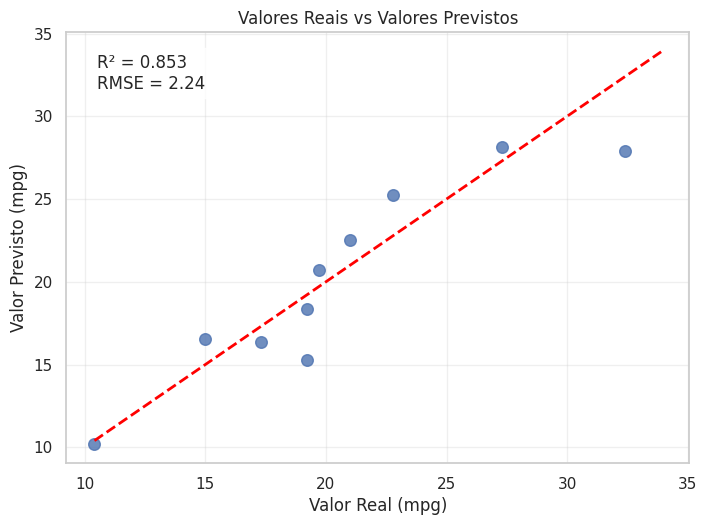

In [626]:
# ============================================================
# Comparação entre valores reais e previstos
# ============================================================
# Este gráfico compara os valores reais de consumo (mpg) com os
# valores previstos pelo modelo de Regressão Linear.
#
# A linha tracejada vermelha representa o cenário ideal, em que
# todas as previsões seriam exatamente iguais aos valores reais.
#
# Quanto mais próximos dessa linha estiverem os pontos,
# menores serão os erros de previsão e melhor será o
# desempenho do modelo.

plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    pred,
    s=70,
    alpha=0.8
)

# Linha de referência (previsão perfeita).
plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    color="red",
    linestyle="--",
    linewidth=2
)

plt.text(
    0.05,
    0.95,
    f"R² = {r2:.3f}\nRMSE = {rmse:.2f}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.xlabel("Valor Real (mpg)")
plt.ylabel("Valor Previsto (mpg)")

plt.title("Valores Reais vs Valores Previstos")

plt.show()

### Interpretação

O modelo apresentou um bom desempenho ao realizar previsões sobre o conjunto de teste.

As métricas obtidas foram:

- **MAE = 1,78:** em média, as previsões diferem aproximadamente **1,78 milhas por galão** dos valores reais.
- **RMSE = 2,24:** mesmo penalizando erros maiores, o modelo apresentou desvios relativamente baixos, indicando boa capacidade preditiva.
- **R² = 0,853:** aproximadamente **85,3% da variabilidade do consumo de combustível** foi explicada pelo modelo em dados que não participaram do treinamento.

Esses resultados indicam que a seleção de variáveis realizada pelo **Backward Elimination** contribuiu para a construção de um modelo mais simples e, ao mesmo tempo, com excelente capacidade de generalização.

Mesmo utilizando apenas três variáveis (**wt**, **qsec** e **am**), o modelo manteve elevado poder explicativo, demonstrando que essas características concentram grande parte das informações necessárias para prever o consumo de combustível.

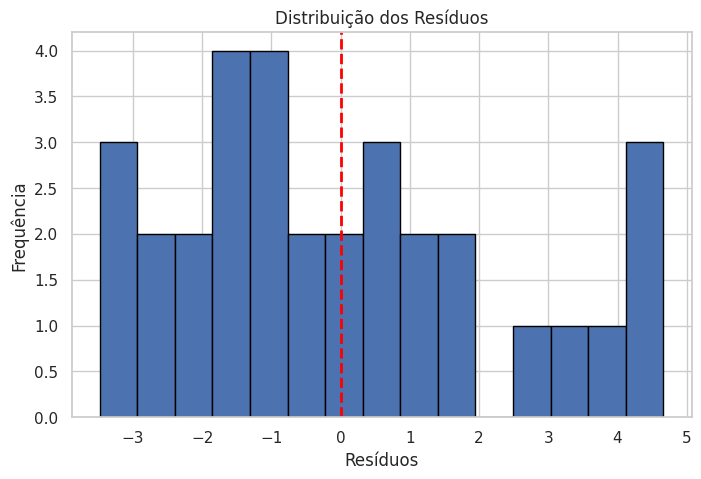

In [627]:
# ============================================================
# Análise dos resíduos
# ============================================================
# Os resíduos representam a diferença entre os valores reais e
# os valores estimados pelo modelo de regressão.
#
# Uma das premissas da Regressão Linear é que esses resíduos
# apresentem distribuição aproximadamente normal e estejam
# centrados em torno de zero.
#
# O histograma permite verificar visualmente se essa condição
# parece ser atendida.

residuos = modelo_ols.resid

plt.figure(figsize=(8,5))

plt.hist(
    residuos,
    bins=15,
    edgecolor="black"
)

# Linha indicando o resíduo igual a zero.
plt.axvline(
    0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Resíduos")
plt.ylabel("Frequência")
plt.title("Distribuição dos Resíduos")

plt.show()

### Interpretação

O histograma apresenta a distribuição dos resíduos do modelo de Regressão Linear.

Observa-se que os resíduos estão distribuídos em torno de zero, sem evidências de um viés sistemático nas previsões. A maior concentração de observações ocorre próxima ao centro da distribuição, enquanto alguns resíduos de maior magnitude aparecem nas extremidades.

Embora a distribuição não seja perfeitamente simétrica, esse comportamento é esperado devido ao reduzido número de observações presentes no dataset (**32 veículos**).

Para complementar a análise visual, a próxima etapa utilizará um teste estatístico de normalidade, permitindo avaliar de forma objetiva se a distribuição dos resíduos é compatível com a hipótese de normalidade.

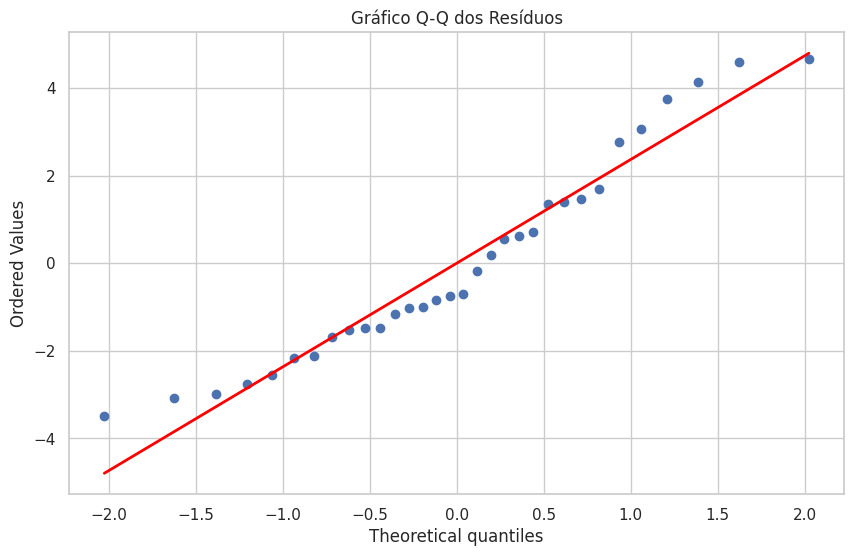

In [628]:
# ============================================================
# Q-Q Plot dos resíduos
# ============================================================
# O gráfico Q-Q (Quantile-Quantile Plot) compara a distribuição
# dos resíduos do modelo com uma distribuição normal teórica.
#
# Se os pontos permanecerem próximos da reta de referência,
# há evidências de que a distribuição dos resíduos é
# aproximadamente normal.
#
# Desvios acentuados da reta, principalmente nas extremidades,
# podem indicar violações da hipótese de normalidade.

stats.probplot(
    residuos,
    dist="norm",
    plot=plt
)

plt.gca().get_lines()[1].set_color("red")
plt.gca().get_lines()[1].set_linewidth(2)

plt.title("Gráfico Q-Q dos Resíduos")

plt.show()

### Interpretação

O gráfico Q-Q compara a distribuição dos resíduos do modelo com uma distribuição normal teórica.

Observa-se que a maior parte dos pontos permanece próxima da reta de referência, principalmente na região central da distribuição. Pequenos desvios são percebidos nas extremidades, comportamento esperado em conjuntos de dados com poucas observações.

Visualmente, não há evidências de desvios importantes da normalidade, sugerindo que a hipótese de resíduos aproximadamente normais é razoável para este modelo.

Na sequência, essa conclusão será complementada pelo teste estatístico de Shapiro-Wilk.

In [629]:
# ============================================================
# Teste de normalidade (Shapiro-Wilk)
# ============================================================
# O teste de Shapiro-Wilk verifica estatisticamente se os
# resíduos seguem uma distribuição normal.
#
# Hipóteses:
#
# H0: os resíduos seguem distribuição normal.
# H1: os resíduos não seguem distribuição normal.
#
# Se o p-value for maior que 0,05, não há evidências para
# rejeitar H0.

estatistica, p_valor = stats.shapiro(residuos)

print(f"Estatística: {estatistica:.4f}")
print(f"P-value: {p_valor:.4f}")

Estatística: 0.9411
P-value: 0.0804


### Interpretação

O teste de Shapiro-Wilk foi utilizado para verificar estatisticamente a hipótese de normalidade dos resíduos do modelo.

As hipóteses avaliadas foram:

- **H₀:** os resíduos seguem uma distribuição normal.
- **H₁:** os resíduos não seguem uma distribuição normal.

O teste retornou:

- **Estatística:** 0,9411
- **P-value:** 0,0804

Como o **p-value é superior ao nível de significância de 5%**, não há evidências estatísticas para rejeitar a hipótese de normalidade dos resíduos.

Esse resultado está de acordo com as análises gráficas realizadas anteriormente (histograma e gráfico Q-Q), reforçando que a premissa de normalidade pode ser considerada atendida para o modelo ajustado.

# Conclusão

Este projeto teve como objetivo investigar os fatores associados ao consumo de combustível dos veículos presentes no dataset mtcars.

Durante a análise exploratória foram identificadas fortes correlações entre peso, potência, cilindrada e consumo de combustível, além da presença de multicolinearidade entre diversas variáveis.

A aplicação do método Backward Elimination permitiu reduzir o modelo de dez para apenas três variáveis (wt, qsec e am), mantendo elevado poder explicativo.

O modelo final apresentou R² = 0,850, enquanto a avaliação em dados não utilizados no treinamento resultou em R² = 0,853, além de baixos valores de MAE e RMSE.

A análise dos resíduos (histograma, gráfico Q-Q e teste de Shapiro-Wilk) indicou que as principais premissas da Regressão Linear foram atendidas.

Dessa forma, conclui-se que o modelo desenvolvido apresenta bom equilíbrio entre simplicidade, interpretabilidade e capacidade preditiva.